目标函数2已经定义，销售价格、种植成本、亩产量、预期销售量已从附件中读取。
Iteration 0-11024828.5
Iteration 1-11109088.3125
Iteration 2-11248571.6875
Iteration 3-11311202.0625
Iteration 4-11275908.6875
Iteration 5-11316985.0625
Iteration 6-11350656.3125
Iteration 7-11355546.9375
Iteration 8-11208330.25
Iteration 9-11361377.4375
Iteration 10-11384460.25
Iteration 11-11372860.5625
Iteration 12-11373170.3125
Iteration 13-11415160.5
Iteration 14-11429400.0
Iteration 15-11438789.875
Iteration 16-11446276.1875
Iteration 17-11474120.125
Iteration 18-11481097.875
Iteration 19-11482348.875
Iteration 20-11533685.625
Iteration 21-11556395.25
Iteration 22-11580739.4375
Iteration 23-11591289.0625
Iteration 24-11608774.3125
Iteration 25-11627491.125
Iteration 26-11640457.1875
Iteration 27-11656499.5625
Iteration 28-11675274.4375
Iteration 29-11695346.8125
Iteration 30-11693672.9375
Iteration 31-11715728.1875
Iteration 32-11734433.0
Iteration 33-11769069.25
Iteration 34-11790343.125
Iteration 35-11797314.75
Iteration 36-11803155.875
Ite

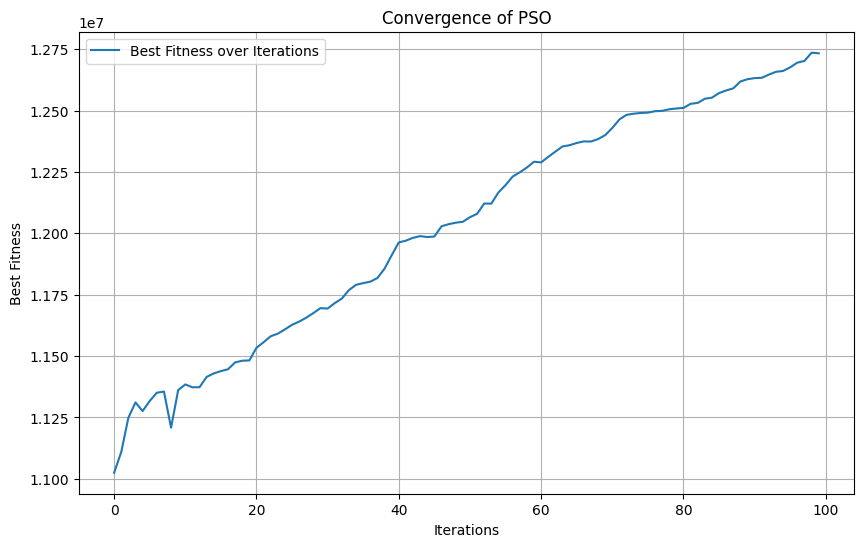

最优解对应的总收益: 12733566.6875
解空间矩阵已输出到文件夹: 2024-09-06_19-17-22


In [19]:
import numpy as np
import os
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt

A_j = [80, 55, 35, 72, 68, 55, 60, 46, 40, 28, 25, 86, 55, 44, 50, 25, 60, 45, 35, 20, 15, 13, 15, 18, 27, 20, 15, 15,
       10, 10, 14, 14, 6, 6, 10, 10, 12, 12, 22, 20, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6,
       0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.3, 0.3, 0.6, 0.6, 0.6, 0.3, 0.3, 0.3, 0.3,
       0.3, 0.3, 0.3, 0.3, 0.6, 0.3, 0.3, 0.6, 0.3, 0.3]
plot_types = ["平旱地", "梯田", "山坡地", "水浇地", "普通大棚", "智慧大棚"]
T_5 = None
T_6 = None




# 粒子群算法的参数
w = 0.5  # 惯性权重
c1 = 1.5  # 个体学习因子
c2 = 1.5  # 社会学习因子
num_particles = 30  # 粒子数量
max_iter = 2000  # 最大迭代次数

# 问题参数（以你的符号定义）
num_years = 7  # 从2024到2030年
num_crops = 41  # 作物种类数
num_plots = 54  # TODO 地块数量
num_seasons = 2  # 季节数量

# 读取附件2.xlsx中的数据
file_path = '附件2.xlsx'

# 读取销售价格（p）、种植成本（c）、亩产量（q）等数据
data_stats = pd.read_excel(file_path, sheet_name='2023年统计的相关数据')

# 将数据转换为字符串，以防止非字符串类型导致错误
data_stats['销售单价/(元/斤)'] = data_stats['销售单价/(元/斤)'].astype(str)

# 获取作物的销售价格（p），使用区间的平均值
p = data_stats['销售单价/(元/斤)'].apply(
    lambda x: (float(x.split('-')[0]) + float(x.split('-')[1])) / 2 if '-' in x else float(x)).values

# 获取作物的种植成本（c）
c = data_stats['种植成本/(元/亩)'].values
# 获取作物的亩产量（q），将产量从‘斤’转换为‘千克’
q = (data_stats['亩产量/斤'].values / 2).astype(float)  # 1斤 = 0.5千克
# 读取2023年农作物种植情况，假设其为预期销售量（D）
data_crop_situation = pd.read_excel(file_path, sheet_name='2023年的农作物种植情况')
# 计算预期销售量 D：使用种植面积/亩 乘以 对应作物的亩产量（q）
D = (data_crop_situation['种植面积/亩'].values * q[data_crop_situation['作物编号'].values - 1])
# 输出目标函数2定义和参数读取部分
print("目标函数2已经定义，销售价格、种植成本、亩产量、预期销售量已从附件中读取。")
# 初始化
particles = np.random.rand(num_particles, num_crops, num_plots, num_seasons, num_years)  # 粒子的位置









# 
# 
# # 施加约束的函数
# def apply_constraints(particles):
#     for n in range(num_particles):
#         for j in range(num_plots):
#             # 地块种植面积不超过总面积
#             for k in range(num_seasons):
#                 for t in range(num_years):
#                     if np.sum(particles[n][:, j, k, t]) > A_j[j]:
#                         particles[n][:, j, k, t] *= A_j[j] / np.sum(particles[n][:, j, k, t])
#             # 地块类型与作物类型的适应性约束
#             for i in range(num_crops):
#                 for k in range(num_seasons):
#                     for t in range(num_years):
#                         if plot_types[j] in [T_5] and k == 2 and i in [35, 36, 37]:  # 普通大棚限制
#                             particles[n][i, j, k, t] = 0
#                         if plot_types[j] in [T_6] and i in [35, 36, 37]:  # 智慧大棚限制
#                             particles[n][i, j, k, t] = 0
#             # 禁止重茬种植约束
#             for i in range(num_crops):
#                 for k in range(num_seasons):
#                     for t in range(num_years - 1):
#                         if particles[n][i, j, k, t] > 0:
#                             particles[n][i, j, k, t + 1] = 0
#             # 豆类作物种植频率限制
#             for t in range(num_years - 2):
#                 if np.sum(particles[n][i, j, :, t:t+3]) < A_j[j]:
#                     particles[n][i, j, :, t:t+3] = A_j[j] / 3
#             # 作物种植集中度约束
#             for i in range(num_crops):
#                 for k in range(num_seasons):
#                     for t in range(num_years):
#                         if particles[n][i, j, k, t] < 0.1 and particles[n][i, j, k, t] > 0:
#                             particles[n][i, j, k, t] = 0.1
#             # 种植面积为0.1的倍数的约束
#             for i in range(num_crops):
#                 for k in range(num_seasons):
#                     for t in range(num_years):
#                         particles[n][i, j, k, t] = ensure_tenth_multiples(particles[n][i, j, k, t])

# 




# apply_constraints(particles)

velocities = np.random.rand(num_particles, num_crops, num_plots, num_seasons, num_years)  # 粒子的速度
p_best = np.copy(particles)  # 每个粒子的最佳位置
g_best = np.copy(particles[0])  # 全局最佳位置
best_fitness_over_time = []


# 确保x是0.1的倍数
def ensure_tenth_multiples(x):
    return np.round(x * 10) / 10


# 目标函数1
def objective_function1(x):
    Z1 = 0
    for t in range(num_years):
        for k in range(num_seasons):
            for i in range(num_crops):
                y_ikt = np.sum(x[i, :, k, t]) * q[i]
                Z1 += p[i] * min(y_ikt, D[i]) - c[i] * np.sum(x[i, :, k, t])
    return Z1  # 由于PSO算法是求最大化问题，直接返回Z1


# 目标函数2的定义
def objective_function2(x):
    Z2 = 0
    for t in range(num_years):
        for k in range(num_seasons):
            for i in range(num_crops):
                y_ikt = np.sum(x[i, :, k, t]) * q[i]
                # 计算收益，考虑滞销部分按折扣价出售
                Z2 += p[i] * min(y_ikt, D[i]) + (0.5 * p[i]) * max(y_ikt - D[i], 0) - c[i] * np.sum(x[i, :, k, t])
    return Z2  # 由于PSO算法是求最大化问题，直接返回Z2


# 粒子群算法主函数
def pso():
    global g_best, p_best, best_fitness_over_time
    for iter in range(max_iter):
        if iter % 100 == 0 and iter > 1:
            # 绘制核心图表
            plt.figure(figsize=(10, 6))
            plt.plot(range(max_iter), best_fitness_over_time, label='Best Fitness over Iterations')
            plt.xlabel('Iterations')
            plt.ylabel('Best Fitness')

            plt.title('Convergence of PSO')
            plt.legend()
            plt.grid()
            plt.savefig(f"{folder_name}/Convergence_PSO.png")
            plt.show()
        for n in range(num_particles):
            fitness = objective_function1(particles[n])
            p_best_fitness = objective_function1(p_best[n])
            g_best_fitness = objective_function1(g_best)
            # 更新个体最佳位置
            if fitness > p_best_fitness:  # 改为最大化
                p_best[n] = particles[n]
            # 更新全局最佳位置
            if fitness > g_best_fitness:  # 改为最大化
                g_best = particles[n]
            # 更新粒子的速度和位置
            velocities[n] = w * velocities[n] + c1 * np.random.rand() * (
                    p_best[n] - particles[n]) + c2 * np.random.rand() * (g_best - particles[n])
            particles[n] += velocities[n]
            # 非负性约束：强制所有位置为非负
            particles[n] = np.maximum(particles[n], 0)
            # 强制x为0.1的倍数
            particles[n] = ensure_tenth_multiples(particles[n])
        # 记录每次迭代后的全局最佳适应度
        best_fitness_over_time.append(g_best_fitness)
        print("Iteration " + str(iter) + str(-g_best_fitness))
    return g_best


# 运行粒子群算法
best_solution = pso()
best_value = objective_function1(best_solution)  # 计算最优解对应的目标函数值
# 创建文件夹，命名为当前日期+时间
folder_name = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
os.makedirs(folder_name, exist_ok=True)
# 输出x解空间矩阵到多个csv文件
for t in range(num_years):
    for k in range(num_seasons):
        df = pd.DataFrame(best_solution[:, :, k, t], columns=[f"P_{j + 1}" for j in range(num_plots)],
                          index=[f"C_{i + 1}" for i in range(num_crops)])
        file_name = f"{folder_name}/{2024 + t}_Season_{k + 1}.csv"
        df.to_csv(file_name)
# 绘制核心图表
plt.figure(figsize=(10, 6))

plt.plot(range(max_iter), best_fitness_over_time, label='Best Fitness over Iterations')
# plt.plot(range(0, max_iter, 100), best_fitness_over_time[::100], label='Best Fitness over Iterations')

plt.xlabel('Iterations')
plt.ylabel('Best Fitness')
plt.title('Convergence of PSO')
plt.legend()
plt.grid()
plt.savefig(f"{folder_name}/Convergence_PSO.png")
plt.show()
print("最优解对应的总收益:", best_value)
print(f"解空间矩阵已输出到文件夹: {folder_name}")



